# KF7029 — Deep SVDD: K-Pipelines Augmented Dataset
**Student:** Sibtain Mehdi Razvi Syed | **ID:** W25039720

## Overview
This notebook implements Deep Support Vector Data Description (Deep SVDD) on the K-Pipelines Augmented dataset.

Deep SVDD trains a neural network to map normal images into a compact hypersphere. At inference, images far from the centre are flagged as anomalous.

**Key implementation requirements (Ruff et al. 2018):**
- bias=False on all layers — prevents hypersphere collapse
- Two-phase training: pretrain with reconstruction, then SVDD objective
- Centre initialised after pretraining on normal data

**Reference:** Ruff et al. (2018). Deep One-Class Classification. ICML.

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('All libraries imported successfully')
print('Device:', device)

All libraries imported successfully
Device: cpu


## 2. Dataset Loading — Augmented Split

In [2]:
BASE_PATH  = r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\k-pipelines\K-Pipelines-main\K-Pipelines-main\Augmented'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VALID_PATH = os.path.join(BASE_PATH, 'valid')
TEST_PATH  = os.path.join(BASE_PATH, 'test')

IMAGE_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
valid_dataset = ImageFolder(VALID_PATH, transform=transform)
test_dataset  = ImageFolder(TEST_PATH,  transform=transform)

# Normal images only for training
normal_class   = train_dataset.class_to_idx['no_corrosion']
corrosion_cls  = test_dataset.class_to_idx['corrosion']
normal_indices = [i for i, (_, label) in enumerate(train_dataset.samples)
                  if label == normal_class]
train_normal   = Subset(train_dataset, normal_indices)

train_loader = DataLoader(train_normal,  batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', train_dataset.classes)
print(f'Normal training images: {len(train_normal)}')
print(f'Test images: {len(test_dataset)}')

Classes: ['corrosion', 'no_corrosion']
Normal training images: 434
Test images: 108


## 3. Deep SVDD Architecture
Three convolutional blocks followed by a fully connected embedding layer. bias=False on all layers prevents hypersphere collapse.

In [3]:
class DeepSVDD(nn.Module):
    def __init__(self, embed_dim=128):
        super(DeepSVDD, self).__init__()
        # bias=False on ALL layers — critical to prevent hypersphere collapse
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),   nn.LeakyReLU(0.1), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),  nn.LeakyReLU(0.1), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.LeakyReLU(0.1), nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(128 * 16 * 16, embed_dim, bias=False)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = DeepSVDD(embed_dim=128).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

DeepSVDD(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.1)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): LeakyReLU(negative_slope=0.1)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.1)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=32768, out_features=128, bias=False)
)

Total parameters: 4,287,328


## 4. Phase 1 — Pretrain with Reconstruction Loss
Pretraining with reconstruction objective gives the network meaningful initial weights before SVDD training. Without this, the network may collapse immediately.

=== Phase 1: Pretraining ===
Pretrain Epoch [10/30]  Loss: 0.070222
Pretrain Epoch [20/30]  Loss: 0.063764
Pretrain Epoch [30/30]  Loss: 0.054697


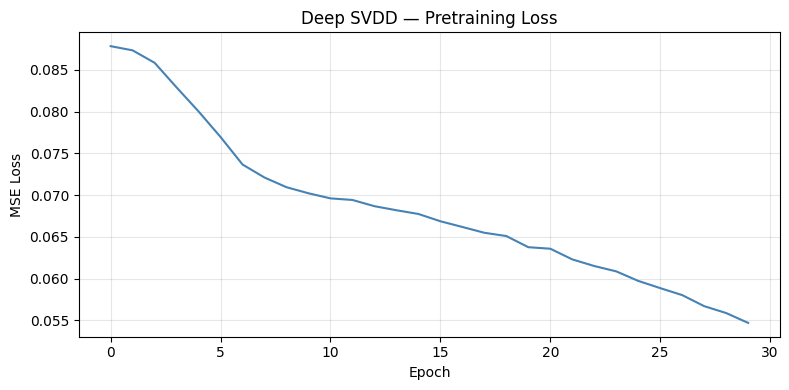

Pretraining complete.


In [4]:
class PretrainNet(nn.Module):
    def __init__(self, encoder):
        super(PretrainNet, self).__init__()
        self.encoder = encoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 128 * 16 * 16, bias=False),
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 2, stride=2, bias=False), nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64, 32, 2, stride=2, bias=False),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32, 3, 2, stride=2, bias=False),   nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

pretrain_net      = PretrainNet(model).to(device)
pretrain_optimizer = torch.optim.Adam(pretrain_net.parameters(), lr=1e-4, weight_decay=1e-5)
criterion         = nn.MSELoss()
pretrain_losses   = []
PRETRAIN_EPOCHS   = 30

print('=== Phase 1: Pretraining ===')
for epoch in range(PRETRAIN_EPOCHS):
    pretrain_net.train()
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        pretrain_optimizer.zero_grad()
        loss = criterion(pretrain_net(images), images)
        loss.backward()
        pretrain_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Pretrain Epoch [{epoch+1}/{PRETRAIN_EPOCHS}]  Loss: {avg_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(pretrain_losses, color='steelblue')
plt.title('Deep SVDD — Pretraining Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\svdd_aug_pretrain_loss.png', dpi=150)
plt.show()
print('Pretraining complete.')

## 5. Initialise Hypersphere Centre
Centre c is the mean embedding of all normal training images after pretraining.

In [5]:
def initialise_centre(model, dataloader, device):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for images, _ in dataloader:
            embeddings.append(model(images.to(device)))
    embeddings = torch.cat(embeddings, dim=0)
    centre = embeddings.mean(dim=0)
    centre[(abs(centre) < 0.01)] = 0.01
    return centre

centre = initialise_centre(model, train_loader, device)
print('Centre shape:', centre.shape)
print('Centre mean: ', centre.mean().item())
print('Centre std:  ', centre.std().item())

# Verify no collapse
model.eval()
with torch.no_grad():
    imgs_batch = next(iter(test_loader))[0][:4].to(device)
    embs = model(imgs_batch)
    diff = torch.norm(embs[0] - embs[1]).item()
    print(f'\nEmbedding difference between two images: {diff:.4f}')
    print('(Must be > 0 — if 0.0000 the network has collapsed)')

Centre shape: torch.Size([128])
Centre mean:  0.08367129415273666
Centre std:   1.9945238828659058

Embedding difference between two images: 41.4188
(Must be > 0 — if 0.0000 the network has collapsed)


## 6. Phase 2 — SVDD Training
Minimise mean squared distance of normal training embeddings from centre c.

=== Phase 2: SVDD Training ===
SVDD Epoch [10/50]  Loss: 16.292698
SVDD Epoch [20/50]  Loss: 8.484843
SVDD Epoch [30/50]  Loss: 6.764418
SVDD Epoch [40/50]  Loss: 5.877810
SVDD Epoch [50/50]  Loss: 5.044013


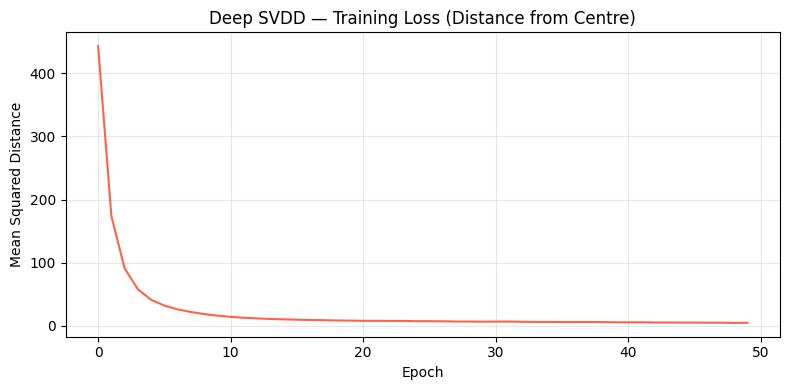

SVDD training complete.


In [6]:
svdd_optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
SVDD_EPOCHS    = 50
svdd_losses    = []

print('=== Phase 2: SVDD Training ===')
for epoch in range(SVDD_EPOCHS):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        svdd_optimizer.zero_grad()
        dist = torch.sum((model(images) - centre) ** 2, dim=1)
        loss = torch.mean(dist)
        loss.backward()
        svdd_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    svdd_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'SVDD Epoch [{epoch+1}/{SVDD_EPOCHS}]  Loss: {avg_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(svdd_losses, color='tomato')
plt.title('Deep SVDD — Training Loss (Distance from Centre)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\svdd_aug_training_loss.png', dpi=150)
plt.show()
print('SVDD training complete.')

## 7. Evaluation
Anomaly score = squared distance from hypersphere centre. Threshold at 50th percentile for balanced test set.

In [7]:
model.eval()
all_scores = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        dist   = torch.sum((model(images) - centre) ** 2, dim=1)
        all_scores.extend(dist.cpu().numpy())
        all_labels.extend(labels.numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)
all_labels_remapped = (all_labels == corrosion_cls).astype(int)

print(f'Test images: {len(all_labels_remapped)}')
print(f'Normal: {(all_labels_remapped==0).sum()} | Anomalous: {(all_labels_remapped==1).sum()}')
print(f'Score range: {all_scores.min():.4f} — {all_scores.max():.4f}')

threshold  = np.percentile(all_scores, 50)
svdd_preds = (all_scores > threshold).astype(int)

svdd_results = {
    'ROC-AUC':   round(roc_auc_score(all_labels_remapped, all_scores), 4),
    'PR-AUC':    round(average_precision_score(all_labels_remapped, all_scores), 4),
    'F1':        round(f1_score(all_labels_remapped, svdd_preds), 4),
    'Precision': round(precision_score(all_labels_remapped, svdd_preds), 4),
    'Recall':    round(recall_score(all_labels_remapped, svdd_preds), 4)
}

print('\n=== Deep SVDD Results ===')
for metric, value in svdd_results.items():
    print(f'  {metric}: {value}')

Test images: 108
Normal: 54 | Anomalous: 54
Score range: 0.1951 — 127.0179

=== Deep SVDD Results ===
  ROC-AUC: 0.6821
  PR-AUC: 0.739
  F1: 0.6667
  Precision: 0.6667
  Recall: 0.6667


## 8. Score Distribution Visualisation

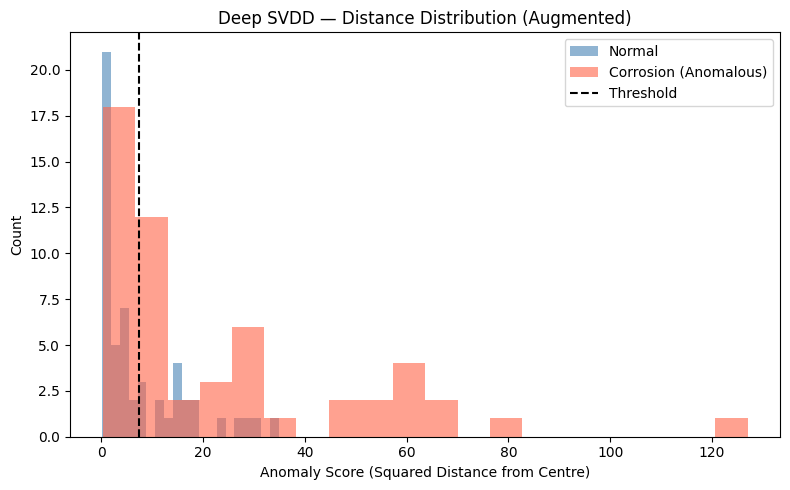

Normal mean distance:    7.7260
Corrosion mean distance: 23.0632
Separation ratio: 2.99x


In [8]:
normal_scores    = all_scores[all_labels_remapped == 0]
corrosion_scores = all_scores[all_labels_remapped == 1]

plt.figure(figsize=(8, 5))
plt.hist(normal_scores,    bins=20, alpha=0.6, color='steelblue', label='Normal')
plt.hist(corrosion_scores, bins=20, alpha=0.6, color='tomato',    label='Corrosion (Anomalous)')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold')
plt.title('Deep SVDD — Distance Distribution (Augmented)')
plt.xlabel('Anomaly Score (Squared Distance from Centre)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\svdd_aug_score_dist.png', dpi=150)
plt.show()

print(f'Normal mean distance:    {normal_scores.mean():.4f}')
print(f'Corrosion mean distance: {corrosion_scores.mean():.4f}')
print(f'Separation ratio: {corrosion_scores.mean() / normal_scores.mean():.2f}x')

## 9. Complete Image Results Summary

=== COMPLETE IMAGE RESULTS — AUGMENTED DATASET ===
                            ROC-AUC  PR-AUC      F1  Precision  Recall
Conv Autoencoder             0.4321  0.4486  0.4630     0.4630  0.4630
Isolation Forest (Encoder)   0.6190  0.6598  0.5926     0.5926  0.5926
One-Class SVM (Encoder)      0.5398  0.5337  0.5185     0.5185  0.5185
Deep SVDD                    0.6821  0.7390  0.6667     0.6667  0.6667


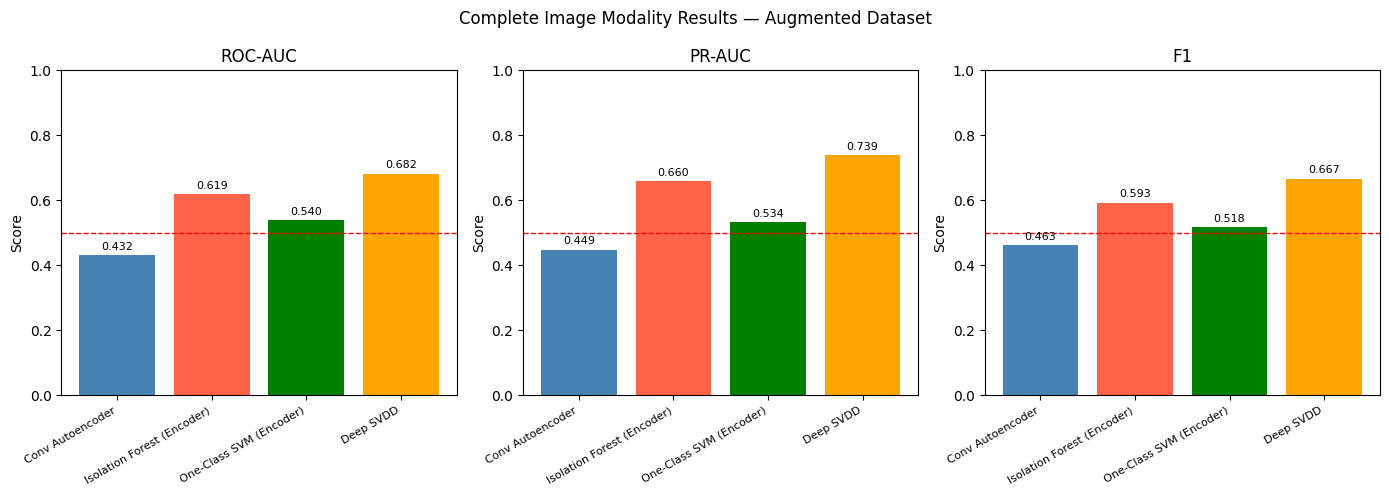

In [9]:
BASE = r'C:\Users\Administrator\Documents\kf7029-w25039720'

# Load previous image results and add Deep SVDD
try:
    with open(fr'{BASE}\results\image_aug_results.pkl', 'rb') as f:
        all_image_results = pickle.load(f)
except:
    all_image_results = {}

all_image_results['Deep SVDD'] = svdd_results

results_df = pd.DataFrame(all_image_results).T
print('=== COMPLETE IMAGE RESULTS — AUGMENTED DATASET ===')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['ROC-AUC', 'PR-AUC', 'F1']
colors  = ['steelblue', 'tomato', 'green', 'orange']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=colors[:len(results_df)])
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Complete Image Modality Results — Augmented Dataset', fontsize=12)
plt.tight_layout()
plt.savefig(fr'{BASE}\results\figures\aug_complete_comparison.png', dpi=150)
plt.show()

## 10. Save Results and Model

In [10]:
results_df.to_csv(fr'{BASE}\results\image_aug_results_complete.csv')

with open(fr'{BASE}\results\image_aug_results_complete.pkl', 'wb') as f:
    pickle.dump(all_image_results, f)

torch.save(model.state_dict(),
    fr'{BASE}\models\saved_models\deep_svdd_aug.pth')
torch.save(centre,
    fr'{BASE}\models\saved_models\deep_svdd_aug_centre.pt')

np.save(fr'{BASE}\datasets\k-pipelines\aug_svdd_scores.npy', all_scores)
np.save(fr'{BASE}\datasets\k-pipelines\aug_svdd_labels.npy', all_labels_remapped)

print('All results and models saved successfully.')

All results and models saved successfully.
